# Data Visualization with Matplotlib and Seaborn

Data visualization is the graphical representation of information and data. By using visual elements like charts, graphs, and maps, data visualization tools provide an accessible way to see and understand trends, outliers, and patterns in data. Additionally, it provides an excellent way for employees or business owners to present data to non-technical audiences without confusion.

## Getting Started with Matplotlib

If not already installed install matplotlib using the pip command

```
!pip install matplotlib
```

In [2]:
import matplotlib.pyplot as plt
import numpy as np

### Simple Example

Matplotlib graphs your data on `Figures` (e.g., windows, Jupyter widgets, etc.), each of which can contain one or more `Axes`, an area where points can be specified in terms of `x-y` coordinates (or theta-r in a polar plot, `x-y-z` in a 3D plot, etc.). The simplest way of creating a` Figure` with an `Axes` is using `pyplot.subplots`. We can then use `Axes.plot` to draw some data on the `Axes`, and show to display the figure:

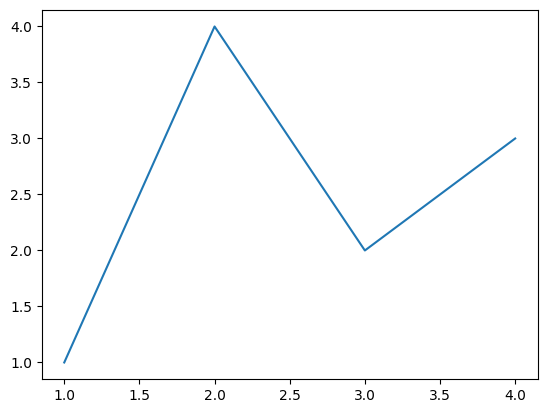

In [3]:
fig, ax = plt.subplots() # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3]) # Plot some data on the Axes.
plt.show() # Show the figure.

Depending on the environment you are working in, `plt.show()` can be left out. This is for example the case with Jupyter notebooks, which automatically show all figures created in a code cell.

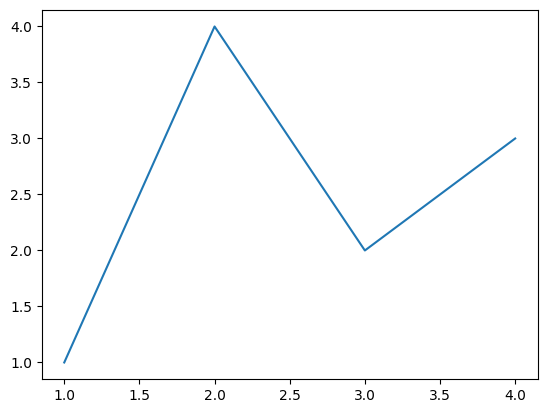

In [4]:
fig, ax = plt.subplots() # Create a figure containing a single Axes.
ax.plot([1, 2, 3, 4], [1, 4, 2, 3]) # Plot some data on the Axes.

### Parts of a Figure

![Parts of a Figure](images/Parts_of_figure.png)

## Seaborn

Seaborn is a Python data visualization library built on top of matplotlib. It provides a high-level interface for creating attractive and informative statistical graphics.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Load dataset
df = sns.load_dataset("penguins")

In [9]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [11]:
df.shape

(344, 7)

In [10]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [12]:
df = df.dropna(axis=0,how='any')

In [13]:
df.shape

(333, 7)

### Bar Plot

#### Simple Bar Plot Using Matplotlib

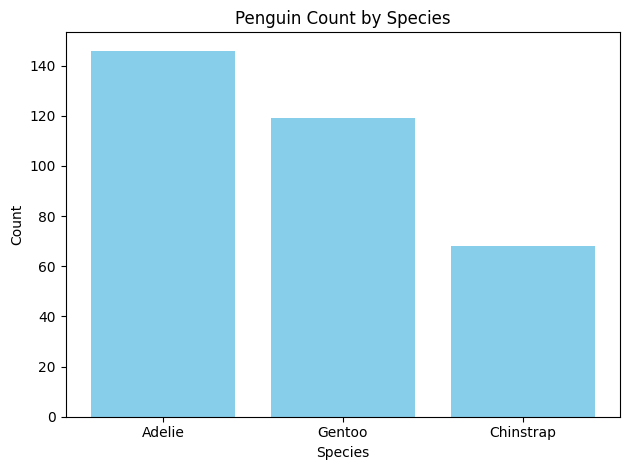

In [16]:
species_counts = df['species'].value_counts()

fig, ax = plt.subplots()
ax.bar(species_counts.index,species_counts.values,color='skyblue')
ax.set_title('Penguin Count by Species')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

#### Simple Bar Plot Using Seaborn

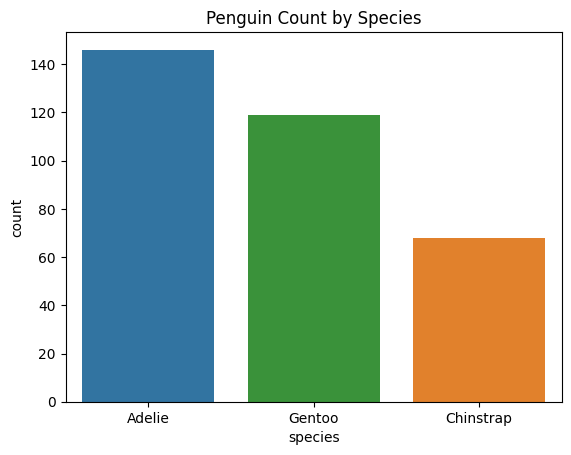

In [21]:
sns.countplot(x='species', data=df, hue='species', order=df['species'].value_counts().index)
plt.title('Penguin Count by Species')
plt.show()

Using the Group by and Aggregate Function

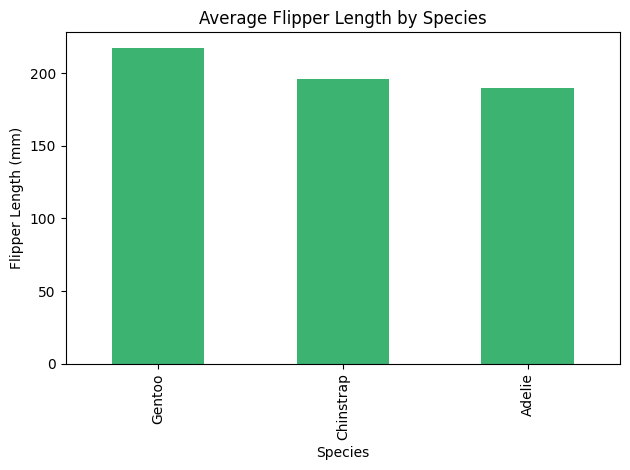

In [22]:
import matplotlib.pyplot as plt

# Calculate average flipper length by species
avg_flipper = df.groupby('species')['flipper_length_mm'].mean().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots()
avg_flipper.plot(kind='bar', color='mediumseagreen', ax=ax)
ax.set_title('Average Flipper Length by Species')
ax.set_ylabel('Flipper Length (mm)')
ax.set_xlabel('Species')
plt.tight_layout()
plt.show()


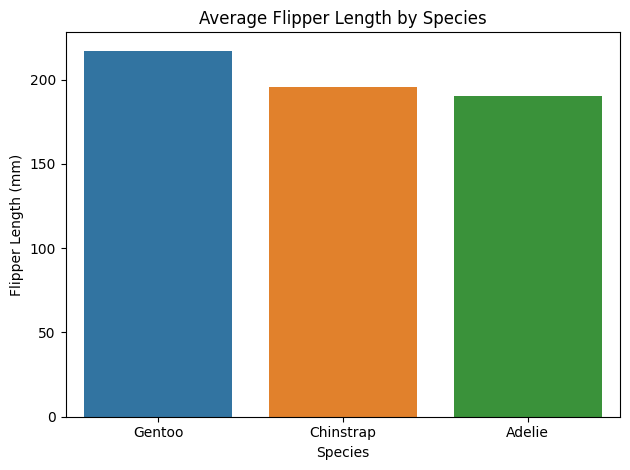

In [24]:
import seaborn as sns

# Pre-calculate average and sort
avg_flipper_df = df.groupby('species', as_index=False)['flipper_length_mm'].mean()
avg_flipper_df = avg_flipper_df.sort_values(by='flipper_length_mm', ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=avg_flipper_df, x='species', y='flipper_length_mm', hue='species', ax=ax)
ax.set_title('Average Flipper Length by Species')
ax.set_ylabel('Flipper Length (mm)')
ax.set_xlabel('Species')
plt.tight_layout()
plt.show()


#### Grouped Bar Chart using Matplotlib

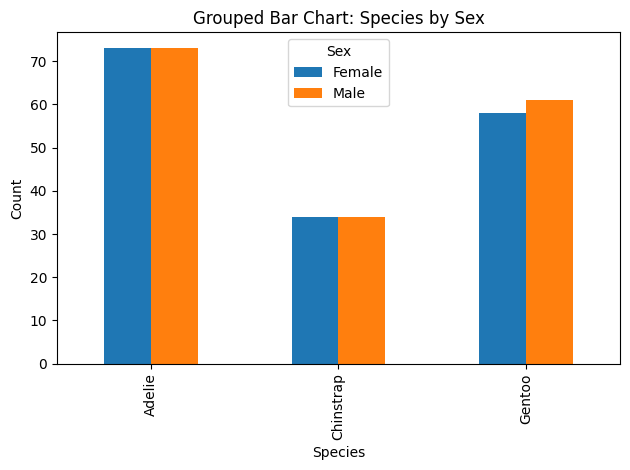

In [26]:
grouped = df.groupby(['species', 'sex']).size().unstack()

fig, ax = plt.subplots()
grouped.plot(kind='bar', ax=ax)
ax.set_title('Grouped Bar Chart: Species by Sex')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

#### Grouped Bar Chart using Seaborn

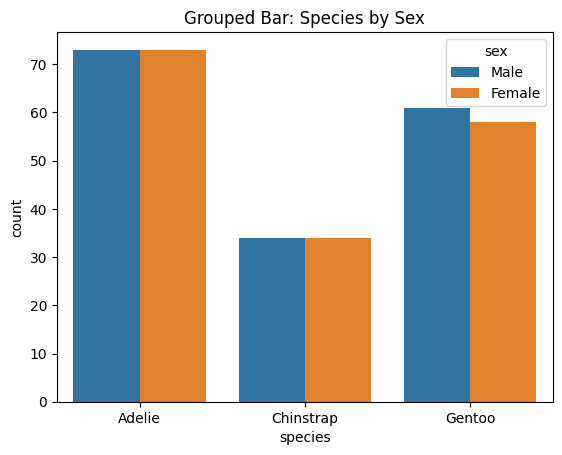

In [30]:
sns.countplot(x='species', hue='sex', data=df)
plt.title('Grouped Bar: Species by Sex')
plt.show()

#### Stacked Bar Chart in Matplotlib

In [32]:
stacked = df.groupby(['species', 'island']).size().unstack()
stacked

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44.0,55.0,47.0
Chinstrap,NaN,68.0,NaN
Gentoo,119.0,NaN,NaN


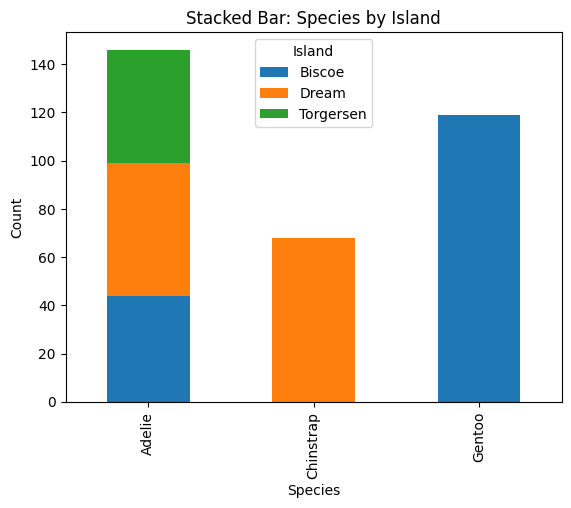

In [33]:
# Using Matplotlib
stacked.plot(kind='bar', stacked=True)
plt.title('Stacked Bar: Species by Island')
plt.xlabel('Species')
plt.ylabel('Count')
plt.legend(title='Island')
plt.show()

Pie Chart

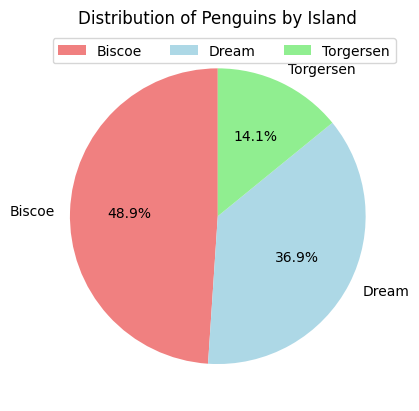

In [40]:
island_counts = df['island'].value_counts()

# Using Matplotlib
island_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue', 'lightgreen'])
plt.title('Distribution of Penguins by Island')
plt.ylabel('')
plt.legend(ncol=3,loc='upper right')
plt.show()

Box Plot

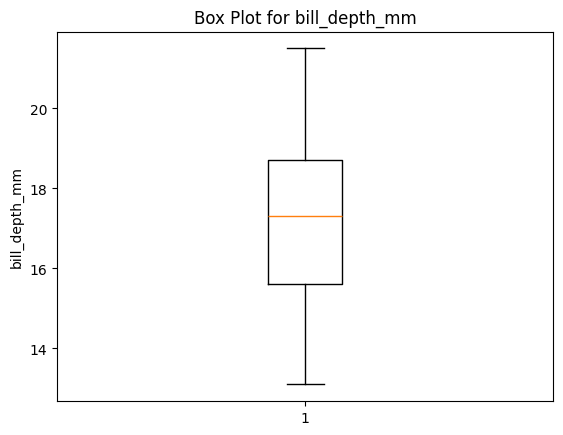

In [44]:
fig, ax = plt.subplots()
ax.boxplot(df['bill_depth_mm'])
ax.set_title("Box Plot for bill_depth_mm")
ax.set_ylabel("bill_depth_mm")
plt.show()

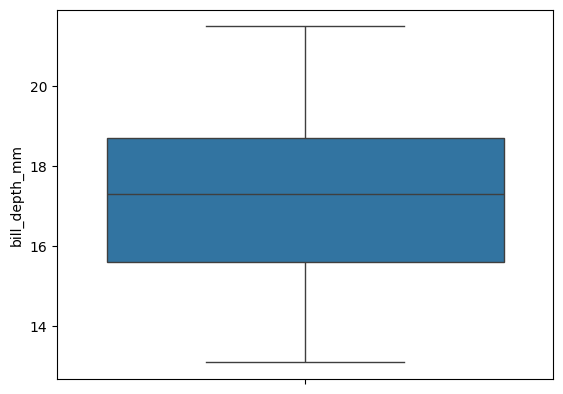

In [51]:
sns.boxplot(y="bill_depth_mm", data=df)
plt.show()

#### Histogram using Matplotlib

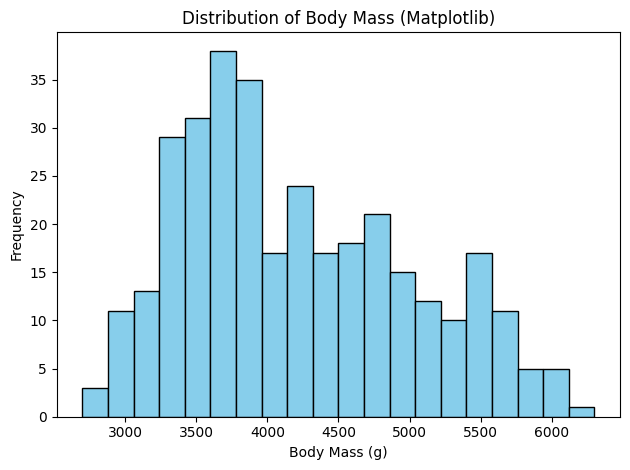

In [53]:
fig, ax = plt.subplots()
ax.hist(df["body_mass_g"], bins=20, color='skyblue', edgecolor='black')

ax.set_title("Distribution of Body Mass (Matplotlib)")
ax.set_xlabel("Body Mass (g)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


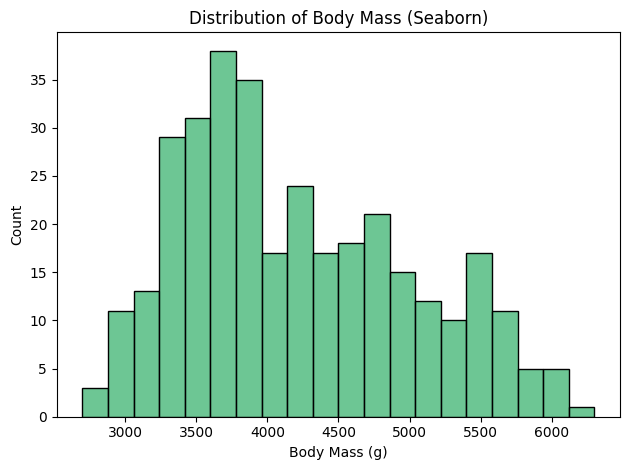

In [54]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="body_mass_g", bins=20, kde=False, color='mediumseagreen', ax=ax)

ax.set_title("Distribution of Body Mass (Seaborn)")
ax.set_xlabel("Body Mass (g)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

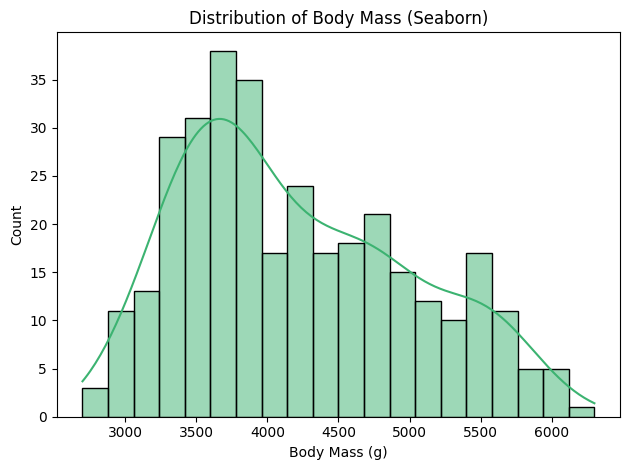

In [55]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="body_mass_g", bins=20, kde=True, color='mediumseagreen', ax=ax)

ax.set_title("Distribution of Body Mass (Seaborn)")
ax.set_xlabel("Body Mass (g)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### BiVariate Analysis

### Numerical Vs Catagorical

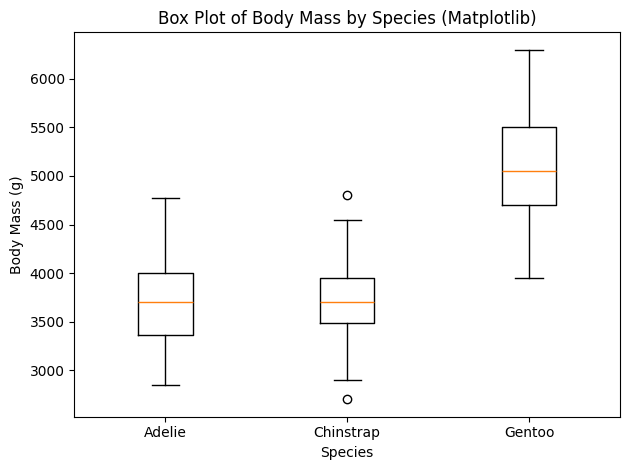

In [65]:
# Prepare data: list of body_mass_g values for each species
species_list = df["species"].unique()
data = [df[df["species"] == species]["body_mass_g"] for species in species_list]

# Create boxplot
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=species_list)

# Customize plot
ax.set_title("Box Plot of Body Mass by Species (Matplotlib)")
ax.set_xlabel("Species")
ax.set_ylabel("Body Mass (g)")

plt.tight_layout()
plt.show()


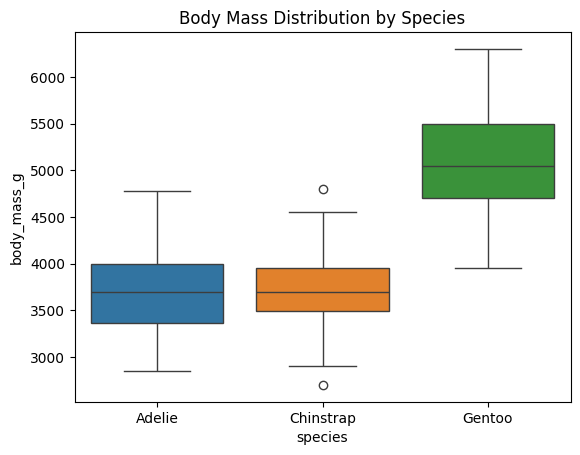

In [61]:
# Using Seaborn
sns.boxplot(x='species', y='body_mass_g', data=df, hue='species')
plt.title('Body Mass Distribution by Species')
plt.show()

Numerical Vs Numerical

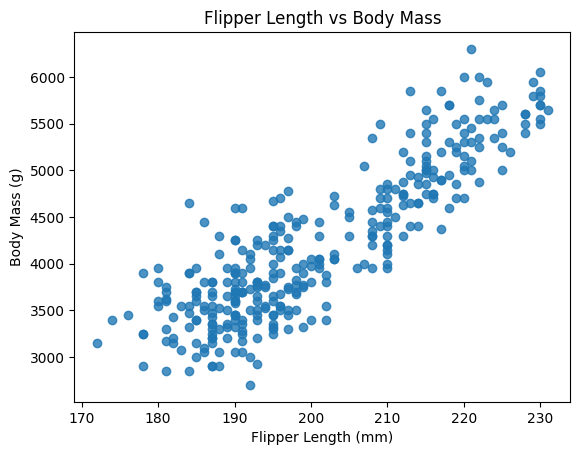

In [72]:
# Using Matplotlib
plt.scatter(df['flipper_length_mm'], df['body_mass_g'], alpha=0.8)
plt.title('Flipper Length vs Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

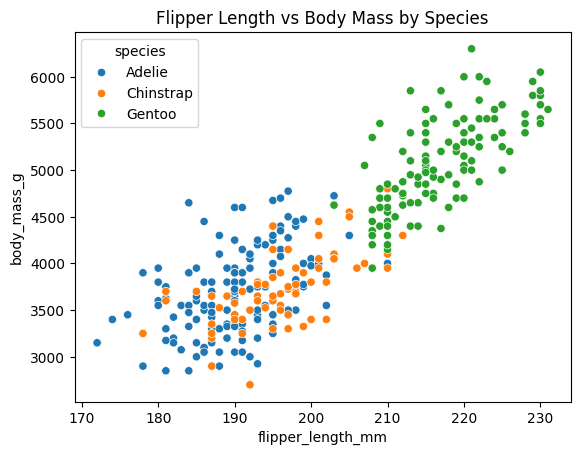

In [67]:
# Using Seaborn
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', hue='species', data=df)
plt.title('Flipper Length vs Body Mass by Species')
plt.show()